In [45]:
import pandas as pd

df = pd.read_csv("../data/HistoricalPrices.csv", skipinitialspace=True)  # delete initial space in the headers
df.columns = df.columns.str.strip()  # delete trailing spaces
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%y")
df = df.set_index('Date')
df.dtypes

Open     float64
High     float64
Low      float64
Close    float64
dtype: object

In [46]:
df.head(10)

,Open,High,Low,Close
Date,,,,
2022-12-14,4015.54,4053.76,3965.65,3995.32
2022-12-13,4069.38,4100.96,3993.03,4019.65
2022-12-12,3939.29,3990.71,3935.30,3990.56
2022-12-09,3954.17,3977.02,3933.04,3934.38
2022-12-08,3947.79,3974.19,3935.83,3963.51
2022-12-07,3933.28,3957.57,3922.68,3933.92
2022-12-06,3996.63,4001.51,3918.39,3941.26
2022-12-05,4052.02,4052.45,3984.49,3998.84
2022-12-02,4040.17,4080.48,4026.63,4071.70


In [47]:
df.head(10)

,Open,High,Low,Close
Date,,,,
2022-12-14,4015.54,4053.76,3965.65,3995.32
2022-12-13,4069.38,4100.96,3993.03,4019.65
2022-12-12,3939.29,3990.71,3935.30,3990.56
2022-12-09,3954.17,3977.02,3933.04,3934.38
2022-12-08,3947.79,3974.19,3935.83,3963.51
2022-12-07,3933.28,3957.57,3922.68,3933.92
2022-12-06,3996.63,4001.51,3918.39,3941.26
2022-12-05,4052.02,4052.45,3984.49,3998.84
2022-12-02,4040.17,4080.48,4026.63,4071.70


In [48]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 11336 entries, 2022-12-14 to 1978-01-03
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    11336 non-null  float64
 1   High    11336 non-null  float64
 2   Low     11336 non-null  float64
 3   Close   11336 non-null  float64
dtypes: float64(4)
memory usage: 442.8 KB


In [49]:
df.describe()

,Open,High,Low,Close
count,11336.000000,11336.000000,11336.000000,11336.000000
mean,1147.131414,1153.915924,1139.663191,1147.246819
std,1032.576554,1038.442665,1026.247182,1032.680497
min,86.900000,87.520000,86.450000,86.900000
25%,310.510000,312.290000,307.585000,310.510000
50%,1026.250000,1032.985000,1017.045000,1025.770000
75%,1442.710000,1452.922500,1433.045000,1443.707500
max,4804.510000,4818.620000,4780.040000,4796.560000


In [50]:
df['Close'].describe().head()

count    11336.000000
mean      1147.246819
std       1032.680497
min         86.900000
25%        310.510000
Name: Close, dtype: float64

In [51]:
df["Change"] = df["Close"] - df["Open"]
df["Change"].describe()

count    11336.000000
mean         0.115405
std         13.477961
min       -150.220000
25%          0.000000
50%          0.000000
75%          0.000000
max        149.540000
Name: Change, dtype: float64

In [54]:
df.index

DatetimeIndex(['2022-12-14', '2022-12-13', '2022-12-12', '2022-12-09',
               '2022-12-08', '2022-12-07', '2022-12-06', '2022-12-05',
               '2022-12-02', '2022-12-01',
               ...
               '1978-01-16', '1978-01-13', '1978-01-12', '1978-01-11',
               '1978-01-10', '1978-01-09', '1978-01-06', '1978-01-05',
               '1978-01-04', '1978-01-03'],
              dtype='datetime64[us]', name='Date', length=11336, freq=None)

In [55]:
df["Return"] = df["Close"].pct_change()
df["Return"].describe()

count    11335.000000
mean        -0.000267
std          0.011346
min         -0.103782
25%         -0.005656
50%         -0.000550
75%          0.004586
max          0.257339
Name: Return, dtype: float64

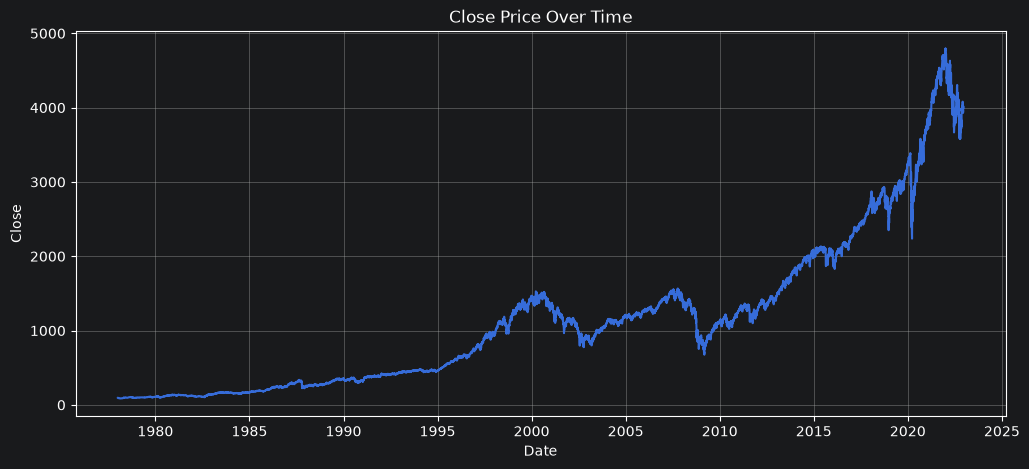

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"])
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Close Price Over Time")
plt.grid(True)
plt.show()

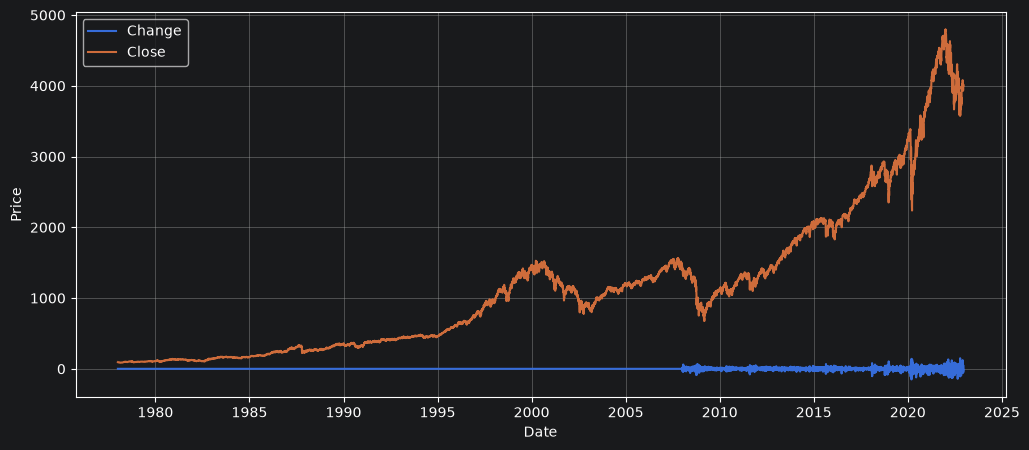

In [63]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Change"], label="Change")
plt.plot(df.index, df["Close"], label="Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()

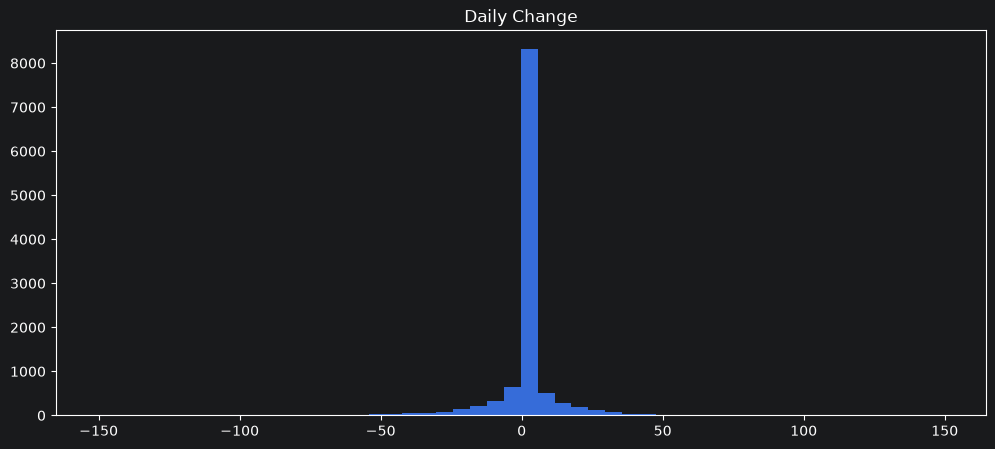

In [64]:
plt.figure(figsize=(12, 5))
plt.hist(df["Change"], bins=50)
plt.title("Daily Change")
plt.show()

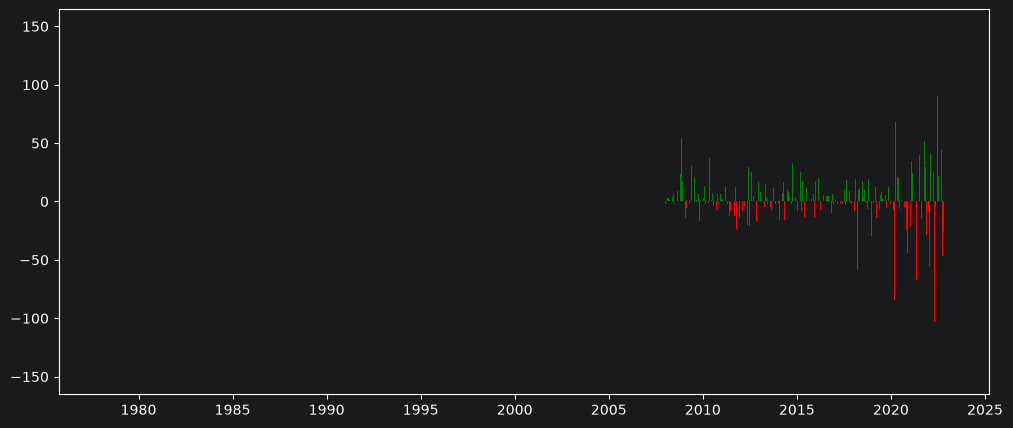

In [66]:
colors = ["green" if x > 0 else "red" for x in df["Change"]]
plt.figure(figsize=(12, 5))
plt.bar(df.index, df["Change"], color=colors)
plt.show()

In [67]:
print(df["High"].max())
print(df["Low"].min())

4818.62
86.45


In [68]:
df["Close"].idxmax()

Timestamp('2022-01-03 00:00:00')

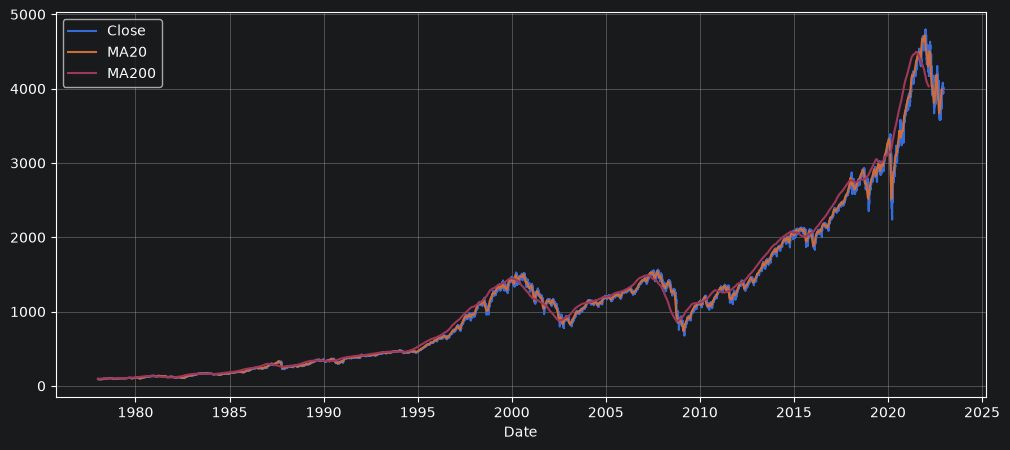

In [70]:
df["MA20"]=df["Close"].rolling(20).mean()
df["MA200"]=df["Close"].rolling(200).mean()
plt.figure(figsize=(12,5))
plt.plot(df.index,df["Close"], label ="Close")
plt.plot(df.index,df["MA20"], label = "MA20")
plt.plot(df.index,df["MA200"], label = "MA200")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()